In [2]:
# # Import important libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
# from xgboost import XGBRegressor
# Load dataset 
df = pd.read_csv("bengaluru_house_prices.csv")

print("First 5 rows : ", df.head())
# print(df.columns)


First 5 rows :                area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  


In [3]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  
(13320, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  obj

In [4]:
print(df.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [5]:
df = df.drop(['society', 'availability'], axis=1)

In [6]:
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

df['bath'] = df['bath'].fillna(df['bath'].median())

df = df.dropna()

In [7]:
df['bhk'] = df['size'].str.split().str[0]
df['bhk'] = df['bhk'].astype(int)

df = df.drop('size', axis=1)

In [8]:
def convert_sqft(x):
    tokens = str(x).split('-')

    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2

    try:
        return float(x)

    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)

df = df.dropna()

In [9]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

In [10]:
df['location'] = df['location'].apply(lambda x: x.strip())

location_stats = df['location'].value_counts()

location_stats_less_than_10 = location_stats[location_stats <= 10]

df['location'] = df['location'].apply(
    lambda x: 'other' if x in location_stats_less_than_10 else x
)

In [11]:
df = df[df['total_sqft'] / df['bhk'] >= 300]

In [12]:
df = df[df['price_per_sqft'] < 20000]

df = df[df['price_per_sqft'] > 1000]

In [13]:
df = df[df['bath'] < df['bhk'] + 2]

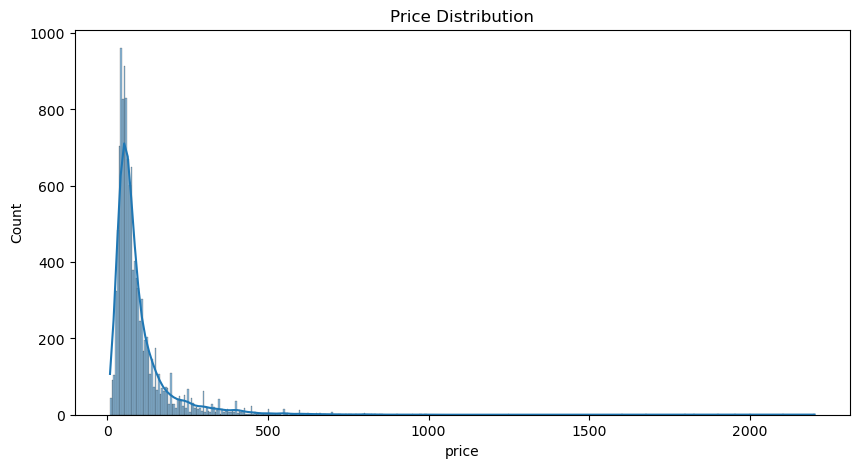

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(df['price'], kde=True)

plt.title("Price Distribution")

plt.show()

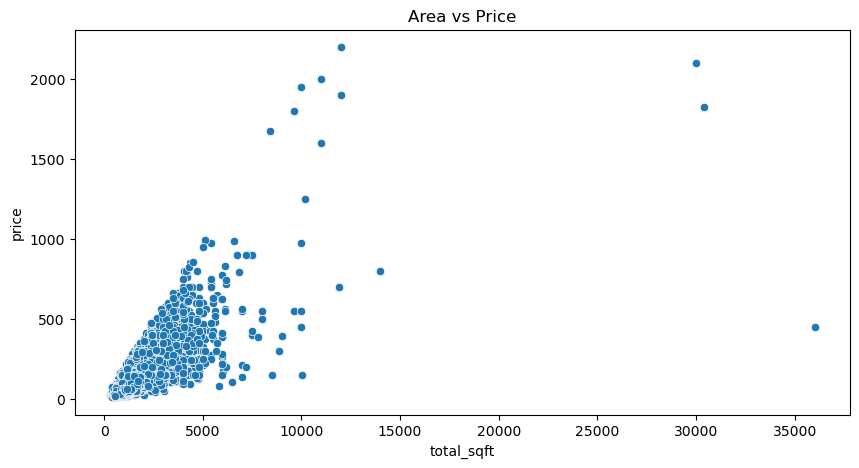

In [15]:
plt.figure(figsize=(10,5))

sns.scatterplot(x=df['total_sqft'], y=df['price'])

plt.title("Area vs Price")

plt.show()

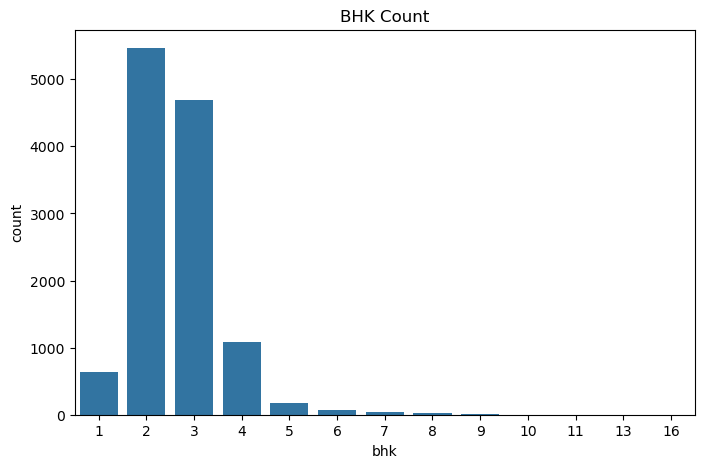

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['bhk'])

plt.title("BHK Count")

plt.show()

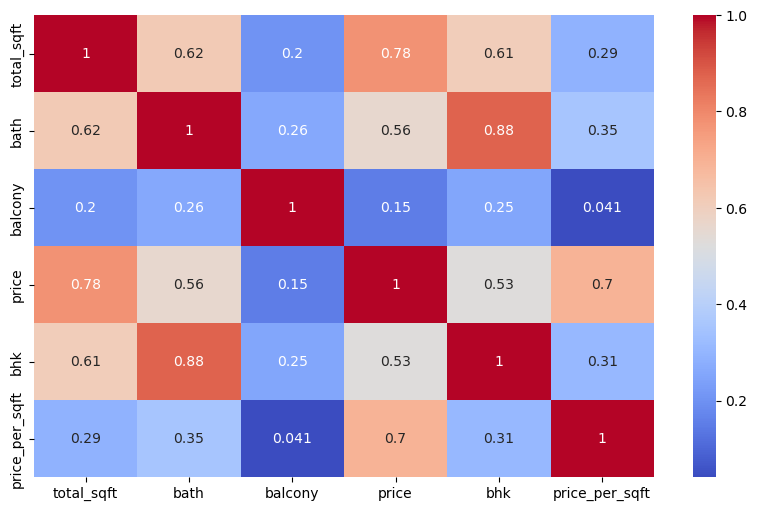

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.show()

In [18]:
df = pd.get_dummies(df, columns=['area_type', 'location'], drop_first=True)

In [19]:
X = df.drop(['price'], axis=1)

y = df['price']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression R2 Score:",
      r2_score(y_test, lr_pred))

Linear Regression R2 Score: 0.8604970231887136


In [22]:
dt = DecisionTreeRegressor(
    max_depth=15,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree R2 Score:",
      r2_score(y_test, dt_pred))

Decision Tree R2 Score: 0.936410138152027


In [23]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2 Score:",
      r2_score(y_test, rf_pred))

Random Forest R2 Score: 0.9862229159787566


In [24]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting R2 Score:",
      r2_score(y_test, gb_pred))

Gradient Boosting R2 Score: 0.9974714357590738


In [25]:
models = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
        
    ],

    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        
    ]
})

print(models)

               Model  R2 Score
0  Linear Regression  0.860497
1      Decision Tree  0.936410
2      Random Forest  0.986223
3  Gradient Boosting  0.997471


In [26]:
best_model = gb

In [31]:
import pickle

pickle.dump(best_model, open("real_estate_model.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

In [28]:
sample = X_test.iloc[0:1]

prediction = best_model.predict(sample)

print("Predicted Price:", prediction)

Predicted Price: [39.21794731]
